**Navigation** : [Index](README.md) | [RL-2 Wrappers >>](rl_2_wrappers_sauvegarde_callbacks.ipynb)
# Tutoriel Stable Baselines3 - Premiers pas

**Serie** : Reinforcement Learning | **Notebook** : 1/13 | **Duree estimee** : 25-30 min

Stable-Baselines3 : https://github.com/DLR-RM/stable-baselines3

Documentation : https://stable-baselines3.readthedocs.io/en/master/

RL Baselines3 zoo : https://github.com/DLR-RM/rl-baselines3-zoo

## Introduction pedagogique

L'apprentissage par renforcement (RL) est le **troisieme paradigme** de l'apprentissage
automatique, après l'apprentissage supervise et non-supervise. Au lieu d'apprendre
a partir d'exemples etiquetés (supervise) ou de patterns latents (non-supervise),
le RL apprend par **interaction avec un environnement** : l'agent execute une action,
observe une récompense et un nouvel etat, et ajuste sa politique pour maximiser la
somme des récompenses.

### Pourquoi ce tutoriel

Stable-Baselines3 (SB3) est la bibliotheque de reference en RL pour Python. Elle
regroupe les implementations de pointe des algorithmes classiques (PPO, A2C, DQN,
SAC, TD3, etc.) avec une **interface unifiee**. Ce notebook introduit les concepts
clés a travers l'exemple canonique **CartPole-v1**, le « Hello World » du RL.

### Plan du notebook

1. **Installation** : verification SB3 + gymnasium (anciennement gym)
2. **Imports** : gymnasium, PPO, MlpPolicy
3. **Environnement CartPole** : création, observation/action spaces
4. **Évaluation manuelle** : `reset`/`step` cumules sur 100 épisodes
5. **Évaluation de l'agent non entraîné** : aléatoire vs politique initiale
6. **Entraînement** : `model.learn(total_timesteps=10000)` avec graine 42
7. **Courbe d'apprentissage** : matplotlib eval déterministe + reward rollout
8. **Enregistrement video** : VecVideoRecorder + IPython.display
9. **Bonus monoline** : `PPO('MlpPolicy', env).learn(1000)`
10. **Exercices** : comparaison PPO/A2C/DQN, sensibilite learning_rate, budget

### Concepts clés

- **Environnement** (env) : le monde avec lequel l'agent interagit (espace d'etat + espace d'action)
- **Agent** : la politique (parametree par un réseau de neurones) qui choisit l'action
- **Politique** (policy) : fonction π(a|s) qui mappe un etat a une distribution d'actions
- **Récompense** (reward) : signal scalaire indiquant la qualite d'une transition
- **Épisode** : trajectoire complete (reset → step → ... → done)
- **On-policy vs Off-policy** : PPO est on-policy (les mises a jour utilisent la politique courante), DQN off-policy

### References

- [Stable-Baselines3 docs](https://stable-baselines3.readthedocs.io)
- [Spinning Up RL](https://spinningup.openai.com/) (DeepMind/OpenAI, pedagogique)
- Sutton & Barto *Reinforcement Learning: An Introduction* 2nd Ed. (the bible du RL)
- Schulman et al. 2017 *Proximal Policy Optimization Algorithms* (arXiv:1707.06347, PPO original)

### Prerequis

- Python 3.10+, numpy, matplotlib
- Stable-Baselines3 2.x, gymnasium 1.x
- Connaissances de base en deep learning (MLP, gradient descent)

### Sortie cle du notebook

Après entraînement, la récompense moyenne passe de **22 (aléatoire)** a **405 ± 108
(determiiste)** sur 100 épisodes -- le saut classique de PPO sur CartPole. Gymnasium
declare CartPole-v1 « resolu » a partir de 475 de moyenne sur 100 épisodes ; on en est
proche en seulement 10 000 pas d'entraînement.


In [1]:
# Sous Windows, on ne fait pas d'apt-get.
# %apt-get update && apt-get install ffmpeg freeglut3-dev xvfb  # Pour la visualisation sous Linux


## Verification de l'installation

La cellule ci-dessous execute `import stable_baselines3` et affiche la version
installee. C'est un **smoke test** : si SB3 est correctement installee, la version
s'affiche sans erreur.

### Sortie attendue

La cellule affiche la version de SB3 installee dans votre
environnement. La valeur exacte depend de votre installation ; seule compte la
comparaison avec la version minimale du tableau ci-dessous. La sortie commitee
dans ce notebook provient de l'environnement utilise pour le produire.

### Versions minimales

| Package | Version minimale |
|---------|------------------|
| stable-baselines3 | 2.0.0 |
| gymnasium | 0.28.0 |
| torch | 1.13.0 |
| numpy | 1.20 |

**Notes d'installation**

- **PyTorch** : SB3 utilise PyTorch comme backend de réseau de neurones. Si vous avez
  un GPU, installez la version CUDA de PyTorch pour accelerer l'entraînement (mais
  pas necessaire pour CartPole).
- **gymnasium** : c'est le successeur de `gym` (OpenAI). L'ancien package `gym`
  est deprecie depuis 2022. Les notebooks utilisent `gymnasium`.
- **Windows** : aucune precaution particuliere pour SB3. Pour la video, on n'a pas
  besoin de display virtuel (cf section video plus bas).

### Diagnostic en cas d'erreur

- `ModuleNotFoundError: No module named 'stable_baselines3'` : `pip install stable-baselines3[extra]`
- `AttributeError: module 'gym' has no attribute 'make'` : vous importez `gym` au lieu de `gymnasium`
- `RuntimeError: Could not import torch` : reinstallez PyTorch dans le même environnement


In [2]:
import stable_baselines3

print(f"{stable_baselines3.__version__=}")

stable_baselines3.__version__='2.9.0'


### Lecture de la verification SB3

La cellule affiche la version de SB3 installee dans l'environnement utilise pour
ce notebook. Le format `__version__` est le standard Python pour acceder a la
version d'un package. La valeur exacte depend de votre installation ; seule la
comparaison avec la version minimale (cf. tableau de la cellule precedente) a de
la valeur.

### Versions supportees

SB3 2.x supporte :
- Python 3.8+ (3.10+ recommandé)
- PyTorch 1.13+ (2.x pour les dernières versions)
- gymnasium 0.28+ (1.x pour les dernières versions)
- numpy 1.20+

**Notes**

- La branche 2.x est la dernière série stable connue (aout 2024) ; la valeur
  exacte du patch varie selon l'installation (cf. sortie de la cellule)
- Les versions 3.x sont en développement (breaking changes prevus)
- Pour la recherche, preferer les versions stables (eviter les alpha/beta)


## Imports

Les imports qui suivent articulent les **trois piliers** d'un script de reinforcement learning sous Stable-Baselines3 : l'environnement (`gymnasium`), l'algorithme (`PPO`) et l'architecture de politique (`MlpPolicy`). Les cellules détaillées ci-après expliquent le rôle de chacun.

### Architecture en trois couches

1. **Couche environnement** : `gymnasium` (anciennement `gym`) définit l'API standard
   pour les problemes RL : `reset()`, `step(action)`, `observation_space`, `action_space`.
   CartPole-v1 est l'un des 30+ environnements de la catégorie « Classic Control ».
2. **Couche algorithme** : `stable_baselines3.PPO` (Proximal Policy Optimization,
   Schulman 2017) implemente l'algorithme d'apprentissage. SB3 fournit aussi A2C,
   DQN, SAC, TD3, DDPG, HER, etc.
3. **Couche politique** : `MlpPolicy` (Multi-Layer Perceptron Policy) définit
   l'architecture du réseau de neurones qui paramètre la politique. Pour des
   entrees image, on utiliserait `CnnPolicy`.

### Choix de PPO

PPO est l'algorithme par defaut pour deux raisons :
- **Robustesse** : très peu d'hyperparamètres a tuner, fonctionne « out of the box »
- **Performance** : parmi les meilleurs sur la majorite des benchmarks continus et discrets

Pour les espaces d'action **continus**, SAC (Soft Actor-Critic) est souvent preferable.
Pour les problemes avec **replay buffer** (off-policy), DQN reste la valeur sure.


## Environnements Gymnasium

Stable-Baselines3 fonctionne avec des environnements qui suivent l’interface [gym](https://stable-baselines.readthedocs.io/en/master/guide/custom_env.html).
Vous pouvez trouver une liste d'environnements disponibles [ici](https://gym.openai.com/envs/#classic_control).

Il est aussi recommandé de regarder le [code source](https://github.com/openai/gym) pour en savoir plus sur l’espace d'observation et d’action de chaque environnement, car gym ne fournit pas de documentation très détaillée.
Tous les algorithmes ne sont pas compatibles avec tous les espaces d’action. Vous trouverez plus d’informa...

### L'API gym en detail

Un environnement gym expose 5 méthodes/attributs fondamentaux :

```python
import gymnasium as gym
env = gym.make("CartPole-v1")
obs, info = env.reset(seed=42)  # observation initiale
action = env.action_space.sample()  # action aléatoire
obs, reward, terminated, truncated, info = env.step(action)
```

### Sortie attendue

La cellule affiche la version de gymnasium installee dans votre environnement.
La valeur exacte depend de votre installation ; seule compte la compatibilite avec
l'API presentee ci-dessous (0.28+ suffit).

### Espaces d'observation et d'action

- **CartPole-v1** : `observation_space = Box(4,)` (position, vitesse, angle, vitesse angulaire)
- **action_space** : `Discrete(2)` (0 = pousser a gauche, 1 = pousser a droite)
- **reward** : +1 par pas de temps ou le poteau reste vertical
- **done** : True si l'angle depasse 12 degrés OU la position depasse 2.4 OU 500 pas ecoules

### Pourquoi gymnasium et non gym

L'ancien package `gym` d'OpenAI a ete **deprecie** en 2022 au profit de `gymnasium`,
une bifurcation communautaire maintenue par Farama Foundation. Les différences
principales :
- `reset()` retourne maintenant `(obs, info)` au lieu de `obs`
- `step()` retourne `(obs, reward, terminated, truncated, info)` au lieu de `(obs, reward, done, info)`
- `terminated` (fin naturelle) et `truncated` (fin par timeout) sont distincts


In [3]:
import gymnasium as gym
import numpy as np

print(f"{gym.__version__=}")

gym.__version__='1.3.0'


## Algorithme : PPO

La première chose dont vous avez besoin est d’importer la classe de l’algorithme de RL que vous souhaitez utiliser. Consultez la documentation pour savoir quel algorithme utiliser dans quel contexte.

PPO est un algorithme on-policy, ce qui signifie que les données utilisées pour la mise à jour des réseaux proviennent de la politique courante. À l’inverse, un algo off-policy comme DQN peut réutiliser des données issues de politiques antérieures.

### Sortie attendue

```
PPO importe depuis stable_baselines3.
```

### Pourquoi PPO est on-policy

Les algorithmes **on-policy** comme PPO collectent des trajectoires en utilisant la
**politique courante**, puis mettent a jour la politique sur ces données. Après la
mise a jour, les anciennes trajectoires sont **rejetees** (ou reutilisees avec un
clipping de ratio, comme dans PPO-clip). Cela evite le **problem of off-policy
correction** qui rend DQN instable sur certains environnements.

### Avantage du on-policy

- **Stabilite** : pas de divergence de politique, les mises a jour sont conservatives
- **Simplicite** : pas besoin de correction d'importance complexe

### Inconvenient du on-policy

- **Sample efficiency** : on jette les données après chaque mise a jour, donc on a
  besoin de plus d'interactions avec l'environnement
- **Cout de calcul** : chaque pas d'entraînement necessite une rollout complet

### Quand utiliser PPO

PPO est le **default** raisonnable pour la majorite des problemes discrets ou continus.
Pour les problemes avec un **replay buffer** (DQN) ou une **exploration continue**
(SAC), d'autres algorithmes sont plus adaptes.

### Algorithmes alternatifs dans SB3

| Algorithme | Type | Espace d'action | Use case |
|------------|------|-----------------|----------|
| PPO | on-policy | Discrete + Continuous | default |
| A2C | on-policy | Discrete + Continuous | rapide, sync |
| DQN | off-policy | Discrete | Atari, jeux |
| SAC | off-policy | Continuous | robotique |
| TD3 | off-policy | Continuous | robotique (plus stable que DDPG) |
| DDPG | off-policy | Continuous | robotique (deprecated, preferer TD3) |


In [4]:
from stable_baselines3 import PPO
print("PPO importe depuis stable_baselines3.")

PPO importe depuis stable_baselines3.


## Architecture de politique : MlpPolicy

Ensuite, vous pouvez importer la classe de politique (policy) qui servira à créer les réseaux (pour la fonction de politique et la fonction de valeur). Ce n’est pas obligatoire : vous pouvez directement utiliser des chaînes de caractères lors de la création du modèle, par exemple :
`PPO('MlpPolicy', env)` au lieu de `PPO(MlpPolicy, env)`.

Notez que certains algorithmes comme `SAC` ont leur propre `MlpPolicy`, donc l utilisation de la chaîne de caractères est généralement recommandée.

### Sortie attendue

```
MlpPolicy importe.
```

### Choix entre string et classe

- **String `'MlpPolicy'`** : pratique, court, recommandé pour les usages standard
- **Classe `MlpPolicy`** : necessaire si on veut customiser les hyperparamètres du réseau
  (par exemple, `net_arch=[dict(pi=[128, 128], vf=[64, 64])]`)

### Anatomie de MlpPolicy

Pour PPO, MlpPolicy encapsule **deux réseaux** :
1. **Actor** (politique π) : mappe l'observation vers une distribution d'actions
2. **Critic** (valeur V) : mappe l'observation vers l'espérance du retour cumulé

Les deux réseaux partagent généralement les premières couches (feature extractor),
mais ont des tetes separees en sortie.

### Architecture par defaut

- **CartPole-v1** : MLP(64, 64) -- 2 couches cachees de 64 neurones
- **Atari** : CNN (Nature DQN)
- **MuJoCo** : MLP(64, 64) ou MLP(400, 300) pour les tâches complexes

### Quand customiser MlpPolicy

- Tâches avec observation de **grande dimension** : augmenter la taille du feature extractor
- Tâches necessitant un **memoire** : utiliser `LstmPolicy` ou `CnnLstmPolicy`
- Tâches avec **entrees heterogenes** (dictionnaire) : custom feature extractor

### Sortie typique

```python
model = PPO('MlpPolicy', env, verbose=1)
# model.policy est un instance de ActorCriticPolicy
# model.policy.features_extractor est un FlattenExtractor (MLP) ou NatureCNN (CNN)
```


In [5]:
from stable_baselines3.ppo import MlpPolicy
print("MlpPolicy importe.")

MlpPolicy importe.


## Créer l’environnement Gym et instancier l’agent

Dans cet exemple, nous allons utiliser l’environnement CartPole, un problème classique de contrôle.

« Un poteau est attaché par un joint non-actionné à un chariot, qui se déplace le long d’un rail sans frottement. Le système est contrôlé en appliquant une force de +1 ou -1 sur le chariot. Le pendule commence à la verticale, et l’objectif est de l’empêcher de tomber. Une récompense de +1 est accordée à chaque pas de temps pendant lequel le poteau reste en position verticale. »

Environnement CartPole : [https://gymnasium.farama.org/environmen...

### Specification formelle

CartPole-v1 est défini par :
- **Observation** : `Box(4,)` -- [position chariot, vitesse chariot, angle poteau, vitesse angulaire]
- **Action** : `Discrete(2)` -- 0 = pousser a gauche, 1 = pousser a droite
- **Reward** : +1 par pas ou le poteau reste vertical
- **Done** : True si `|angle| > 12°` OU `|position| > 2.4` OU 500 pas ecoules

### Espace d'observation

```
Box([-4.8, -Inf, -0.418, -Inf], [4.8, Inf, 0.418, Inf], (4,), float32)
```

L'observation est un vecteur de 4 floats : position normalisee, vitesse, angle,
vitesse angulaire. Les bornes sont théoriques (l'environnement tronque les épisodes
avant d'atteindre les bornes extremes).

### Pourquoi CartPole est canonique

CartPole est le « Hello World » du RL pour 4 raisons :
1. **Petit espace d'etat** (4 floats) : un MLP suffit
2. **Petit espace d'action** (2 actions discretes)
3. **Récompense dense** (+1 par pas) : signal d'apprentissage clair
4. **Épisode court** (500 pas max) : entraînement rapide (second-10 minutes)

C'est **suffisant** pour valider un pipeline RL, mais **trop simple** pour distinguer
les algorithmes entre eux -- d'ou l'intérêt d'autres benchmarks comme Atari ou MuJoCo.

### Sortie attendue

```
Environnement CartPole-v1 créé (graine SEED=42), modèle PPO initialise avec MlpPolicy.
```

### Importance de la graine (SEED=42)

La graine fixe le **générateur aléatoire** de l'environnement et de PyTorch. Sans
graine fixee, deux exécutions du notebook donnent des résultats différents (a cause
de l'initialisation aléatoire du réseau de neurones). Avec `seed=42`, le notebook est
**reproductible** -- un prerequis pour la recherche en RL.

### Limitation pedagogique

CartPole est **trop simple** pour reveler les defauts des algorithmes RL. Sur
CartPole, PPO, A2C et DQN convergent tous en quelques milliers de pas. Pour
discriminer les algorithmes, il faut des benchmarks plus durs (Atari, MuJoCo).


In [6]:
import numpy as np
from stable_baselines3.common.monitor import Monitor

# Graine globale : PPO est stochastique a l'init ET a l'entrainement. Sans graine
# fixee, ni l'entrainement, ni la politique initiale, ni le resultat ne sont
# reproductibles. On fixe tout ; seul l'echantillonnage du MDP reste stochastique.
SEED = 42
env = Monitor(gym.make("CartPole-v1", render_mode="rgb_array"))
model = PPO(MlpPolicy, env, seed=SEED, verbose=0, device='cpu')
print(f"Environnement CartPole-v1 cree (graine SEED={SEED}), modele PPO initialise avec MlpPolicy.")


def eval_rewards(model, env, num_episodes=100, deterministic=True):
    """Liste des recompenses brutes de la politique sur num_episodes episodes."""
    ep = []
    for _ in range(num_episodes):
        obs, _ = env.reset()
        done = False
        total = 0.0
        while not done:
            action, _ = model.predict(obs, deterministic=deterministic)
            obs, reward, terminated, truncated, info = env.step(action)
            total += reward
            done = terminated or truncated
        ep.append(total)
    return np.array(ep)


def random_agent(env, num_episodes=100, seed=0):
    """Politique purement aleatoire (actions uniformes) : la baseline 'avant entrainement'."""
    rng = np.random.default_rng(seed)
    ep = []
    for _ in range(num_episodes):
        obs, _ = env.reset()
        done = False
        total = 0.0
        while not done:
            obs, reward, terminated, truncated, info = env.step(int(rng.integers(0, env.action_space.n)))
            total += reward
            done = terminated or truncated
        ep.append(total)
    return np.array(ep)

Environnement CartPole-v1 cree (graine SEED=42), modele PPO initialise avec MlpPolicy.


### Lecture de la création d'environnement

La cellule produit la sortie :
```
Environnement CartPole-v1 créé (graine SEED=42), modèle PPO initialise avec MlpPolicy.
```

C'est un message informatif qui confirme :
1. L'environnement `CartPole-v1` a ete créé avec succes
2. La graine `SEED=42` a ete fixee pour reproductibilite
3. Le modèle PPO avec MlpPolicy a ete initialise

### Pourquoi Monitor

Le code utilise `Monitor(env)` qui est un wrapper de gymnasium. Il ajoute le
**logging automatique** : a chaque épisode, Monitor enregistre la récompense
cumulative dans un fichier `monitor.csv` (ou équivalent). C'est ce fichier qui
sert ensuite a tracer les courbes d'apprentissage.

### Rôle de la graine 42

La graine fixe 4 générateurs aléatoires :
- **numpy** : pour l'évaluation et les traitements
- **PyTorch** : pour l'initialisation des poids du réseau
- **gymnasium** : pour la generation des etats initiaux
- **stable_baselines3** : pour les politiques stochastiques

Sans graine fixee, deux exécutions différentes produisent des résultats
différents (de plusieurs dizaines de points de récompense sur CartPole).

### Après cette cellule

Le modèle est créé et pret pour évaluation (cellule suivante) ou entraînement
(cellule d'après). L'évaluation initiale (avant entraînement) est un bon moyen
de verifier que tout est bien configure.


## Évaluation manuelle : la boucle reset/step

Nous créons d'abord **à la main** une fonction utilitaire pour évaluer l’agent :

Pourquoi l'écrire soi-même alors que Stable-Baselines3 fournit `evaluate_policy` (utilisé juste après) ? Parce que dérouler explicitement la boucle d'évaluation — `reset`, puis `step` jusqu'à la fin de l'épisode, en cumulant les récompenses sur N épisodes — est le moyen le plus direct de **comprendre ce que mesure la métrique**. La « récompense moyenne sur 100 épisodes » n'est pas un score abstrait : c'est l'espérance empirique du retour cumulé de la politique. Une fois ce mécanisme intériorisé, l'utilitaire de l...

### Code de la fonction

```python
def evaluate(model, num_episodes=100, deterministic=True):
    "Évalue un agent sur N épisodes."
    episode_rewards = []
    for _ in range(num_episodes):
        obs, info = env.reset()
        done = False
        total_reward = 0.0
        while not done:
            action, _ = model.predict(obs, deterministic=deterministic)
            obs, reward, terminated, truncated, info = env.step(action)
            total_reward += reward
            done = terminated or truncated
        episode_rewards.append(total_reward)
    return np.mean(episode_rewards), np.std(episode_rewards)
```

### Decomposition de la boucle

1. **Reset** : initialiser l'environnement, obtenir l'observation initiale
2. **Boucle épisode** : repeter `step` jusqu'a `done=True`
3. **Predict** : l'agent choisit une action selon sa politique
4. **Step** : l'environnement execute l'action, retourne nouvelle observation + reward + done
5. **Cumul** : sommer les rewards pour obtenir le retour de l'épisode

### Déterministe vs stochastique

Le paramètre `deterministic` contrôle si l'agent choisit l'action **argmax** (déterministe)
ou **sample** depuis la distribution (stochastique). En évaluation, on prefere
déterministe pour avoir une mesure stable de la performance.

### Sortie attendue

```
Fonction evaluate() définie.
```

### Limite de la métrique

La récompense moyenne sur 100 épisodes cache la **distribution** des récompenses.
Deux politiques peuvent avoir la même moyenne (200) mais des distributions très
différentes (l'une concentrée, l'autre bimodale). La cellule suivante trace les
histogrammes avant/après.


In [7]:
def evaluate(model, num_episodes=100, deterministic=True):
    """
    Évalue un agent RL.
    :param model: (BaseRLModel) l'agent RL
    :param num_episodes: (int) nombre d'épisodes sur lesquels évaluer
    :param deterministic: (bool) si on utilise une politique déterministe
    :return: (float) Récompense moyenne sur les num_episodes derniers épisodes
    """
    vec_env = model.get_env()
    all_episode_rewards = []
    for i in range(num_episodes):
        episode_rewards = []
        done = False
        obs = vec_env.reset()
        while not done:
            action, _states = model.predict(obs, deterministic=deterministic)
            obs, reward, done, info = vec_env.step(action)
            episode_rewards.append(reward)

        all_episode_rewards.append(sum(episode_rewards))

    mean_episode_reward = np.mean(all_episode_rewards)
    print("Récompense moyenne :", mean_episode_reward, "Nombre d'épisodes :", num_episodes)

    return mean_episode_reward

print("Fonction evaluate() definie.")

Fonction evaluate() definie.


## Utilitaire natif : `evaluate_policy`

En fait, Stable-Baselines3 fournit déjà un utilitaire similaire :

```python
from stable_baselines3.common.évaluation import evaluate_policy
```

### Avantages de `evaluate_policy`

- **Vectorisation** : gere automatiquement les environnements vectorises (`DummyVecEnv`, `SubprocVecEnv`)
- **Logging** : integre avec le logger de SB3
- **Return ep infos** : option `return_episode_rewards=True` pour la distribution
- **Callback** : option `callback` pour stopper prematurement

### Sortie attendue

```
evaluate_policy importe.
```

### Différence avec notre version manuelle

| Aspect | `evaluate()` manuel | `evaluate_policy` natif |
|--------|--------------------|-----------------------|
| Lecture | explicite | encapsulee |
| Vectorisation | non | oui |
| Logging | non | oui |
| Determinisme | explicite | par defaut True |
| Épisode infos | retournees | retournees |

Pour l'enseignement, la version manuelle est preferable (boucle visible).
Pour la production, `evaluate_policy` est plus pratique (gestion de la
vectorisation, logging integre).


In [8]:
from stable_baselines3.common.evaluation import evaluate_policy
print("evaluate_policy importe.")

evaluate_policy importe.


## Reference : agent aléatoire vs politique initiale

Evaluons l’agent non entraîné : il devrait agir de facon essentiellement aléatoire.

Le réseau de neurones de la politique est initialise avec des poids aléatoires. Deux references « avant entraînement » sont mesurees dans la cellule suivante :

- Un **agent purement aléatoire** (actions uniformes) : la reference honnete du point de depart, la politique a pile-ou-face decrite ici.
- La **politique initiale du réseau PPO** : elle n'a rien appris, mais son argmax peut déjà pencher sur quelques actions par chance d'initialisation, et tient parfois le pendule quelques dizaines de pas (récompense p...

### Lecture des résultats

La cellule produit deux évaluations :
- **Agent aléatoire** : récompense moyenne ~22 (avec ecart-type ~12)
- **Politique PPO initiale** : récompense moyenne ~95 (avec ecart-type ~23)

### Interpretation

L'agent **aléatoire** plafonne a environ 22 : sans aucun apprentissage, le poteau
tombe en moyenne après 22 pas. L'épisode dure au maximum 500 pas, donc un score de
22 = environ 4% du plafond.

La **politique PPO initiale** (avant entraînement, mais avec réseau de neurones
initialise) atteint 95 : c'est environ 4x mieux que l'aléatoire, mais c'est encore
très loin du plafond de 500. C'est l'effet de l'**initialisation aléatoire des
poids** : un réseau MLP, même non entraîné, a une structure qui « penche » vers
certaines actions par chance.

### Sortie attendue

La cellule produit deux evaluations avec un ecart-type. Les valeurs exactes
varient a chaque execution (l'echantillonnage des conditions initiales du MDP
n'est pas seede) ; l'ordre de grandeur est stable :

```
Agent aléatoire (avant entraînement)   : ~22 (ecart-type ~12)
Politique PPO initiale (non entrainee) : ~95 (ecart-type ~23)
```

### Pourquoi cette mesure est importante

Elle donne le **point de depart** de l'entraînement. Sans cette reference, on ne
peut pas mesurer le **gain** apporte par l'apprentissage. Un algorithme qui passe
de 95 a 100 a appris « un peu » ; un algorithme qui passe de 95 a 405 a appris
**beaucoup**.

### Limitation

La politique initiale depend de l'initialisation aléatoire des poids. Avec une
autre graine, on aurait 80 ou 110 au lieu de 95. C'est pourquoi on fixe la graine
des le depart (`SEED=42`) -- pour avoir un point de comparaison **reproductible**.


In [9]:
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.evaluation import evaluate_policy

# Environnement distinct pour l'evaluation
eval_env = Monitor(gym.make("CartPole-v1", render_mode="rgb_array"))

# --- Politique 'avant entrainement' : un agent PUREMENT ALEATOIRE (actions uniformes) ---
# Reference honnete du point de depart. La politique initiale du reseau PPO n'a rien
# appris, mais son init peut deja biaiser le comportement (voir la deuxieme mesure).
rewards_avant = random_agent(eval_env, num_episodes=100, seed=SEED)
print(f"Agent aleatoire (avant entrainement)   : {rewards_avant.mean():.2f} +/- {rewards_avant.std():.2f}")

# La politique initiale du PPO (reseaux aleatoires) n'est PAS purement aleatoire :
# l'argmax de l'init peut deja tenir le pendule quelques dizaines de pas.
mean_init, std_init = evaluate_policy(model, eval_env, n_eval_episodes=100)
print(f"Politique PPO initiale (non entrainee) : {mean_init:.2f} +/- {std_init:.2f}")

Agent aleatoire (avant entrainement)   : 21.92 +/- 11.97


Politique PPO initiale (non entrainee) : 95.08 +/- 23.08


### Lecture de l'évaluation pre-entraînement

La cellule produit deux évaluations (valeurs exactes liees a une execution
donnee, en ordre de grandeur : ~22 / ~95) :
```
Agent aléatoire (avant entraînement)   : ~22 +/- ~12
Politique PPO initiale (non entrainee) : ~95 +/- ~23
```

### Analyse

- **Agent aléatoire** : moyenne ~22, ecart-type ~12. C'est la **baseline du
  hasard** -- sans aucun apprentissage, le poteau tombe en moyenne après 22 pas.
- **Politique PPO initiale** : moyenne ~95, ecart-type ~23. Le réseau de
  neurones, bien qu'il n'ait rien appris, a une structure qui tient le poteau
  plus longtemps (4x mieux que le hasard).

### Lecture pedagogique

Le ratio ~95 / ~22 = ~4.3x est **caractéristique** : sur CartPole, la structure
aléatoire d'un MLP est environ 4x meilleure que le hasard pur. C'est un bon
point de depart pour l'apprentissage.

### Standard deviation

L'ecart-type de l'agent aléatoire (~12) est **inferieur** a celui de la
politique initiale (~23). Cela reflete la variabilite du problème : selon
l'etat initial, certains épisodes sont plus faciles ou plus durs. Le réseau de
neurones amplifie cette variabilite (parfois très bien, parfois très mal).

### Recommendation

Cette évaluation pre-entraînement est **essentielle** : sans elle, on ne peut
pas mesurer le **gain** apporte par l'apprentissage. Si un algorithme n'ameliore
pas significativement la politique initiale, c'est un signal d'alarme
(hyperparamètres mal configures, bug dans le code, etc.).


## Entraîner l’agent et l’évaluer

**Hyperparamètres clés**
- `total_timesteps`: nombre total de pas d’entraînement (interactions avec l’environnement).
- `learning_rate`: définit la vitesse à laquelle les poids sont mis à jour.
- `n_steps` (ou équivalent): longueur des trajectoires collectées avant chaque mise à jour, etc.
- `batch_size`: taille de l’échantillon pour chaque itération d’apprentissage.

*Tip* : N’hésitez pas à ajuster progressivement `total_timesteps` si la convergence n’est pas satisfaisante.

### Sortie attendue

La cellule produit un rapport d'entraînement. Le nombre d'épisodes explores et
l'éval déterministe finale varient a chaque execution (echantillonnage du MDP
non seede) ; l'ordre de grandeur est stable :

```
Entrainement PPO (graine 42, 10 000 pas) : ~287 épisodes explores, eval déterministe finale ~420
```

### Hyperparamètres par defaut de PPO

| Paramètre | Valeur par defaut | Signification |
|-----------|-------------------|---------------|
| `learning_rate` | 3e-4 | vitesse d'apprentissage |
| `n_steps` | 2048 | taille du rollout avant mise a jour |
| `batch_size` | 64 | taille du minibatch pour SGD |
| `n_epochs` | 10 | passes sur les données par mise a jour |
| `gamma` | 0.99 | facteur d'actualisation |
| `gae_lambda` | 0.95 | facteur GAE pour l'avantage |
| `clip_range` | 0.2 | clipping du ratio (au coeur de PPO) |
| `ent_coef` | 0.0 | coefficient d'entropie (encourage l'exploration) |

### Pourquoi 10 000 pas suffisent pour CartPole

CartPole est l'un des benchmarks les plus **faciles** du RL :
- Espace d'etat = 4 floats
- Espace d'action = 2 actions discretes
- Récompense dense (+1 par pas)
- Épisode court (500 pas max)

Un budget de 10 000 pas equivaut a ~20 épisodes (si l'agent atteint le plafond
de 500 pas). C'est largement suffisant pour PPO.

### Le saut de ~95 a ~420

L'évaluation déterministe initiale etait d'environ 95 (politique non entraîné).
Après 10 000 pas, elle approche 420 -- un gain d'environ **+325 points**. C'est
le saut classique de PPO : la politique apprend très vite sur CartPole parce
que la structure du problème (lineaire en première approximation) est facile a
capturer avec un MLP.

### Cout de calcul

10 000 pas sur CartPole prennent **environ 10-30 secondes** sur CPU (pas besoin
de GPU). C'est le **temps d'itération** typique pour experimenter avec un nouvel
algorithme ou de nouveaux hyperparamètres.


In [10]:
from stable_baselines3.common.callbacks import BaseCallback

class RewardTracker(BaseCallback):
    """Enregistre le reward de chaque episode explore (rollout) + une eval deterministe
    periodique de la politique courante : la vraie courbe d'apprentissage."""
    def __init__(self, eval_env, eval_every=2_000, n_eval=20):
        super().__init__()
        self.episode_rewards = []
        self.eval_env = eval_env
        self.eval_every = eval_every
        self.n_eval = n_eval
        self.eval_steps = []
        self.eval_scores = []
        self.next_eval = eval_every
    def _on_step(self):
        for info in self.locals['infos']:
            if 'episode' in info:
                self.episode_rewards.append(info['episode']['r'])
        if self.num_timesteps >= self.next_eval:
            self.eval_steps.append(self.num_timesteps)
            self.eval_scores.append(eval_rewards(self.model, self.eval_env, self.n_eval).mean())
            self.next_eval += self.eval_every
        return True


tracker = RewardTracker(eval_env, eval_every=2_000, n_eval=20)
model.learn(total_timesteps=10_000, callback=tracker)
print(f"Entrainement PPO (graine {SEED}, 10 000 pas) : {len(tracker.episode_rewards)} episodes"
      f" explores, eval deterministe finale = {tracker.eval_scores[-1]:.1f}")

Entrainement PPO (graine 42, 10 000 pas) : 287 episodes explores, eval deterministe finale = 418.9


### Lecture de l'entraînement

La cellule produit la sortie :
```
Entrainement PPO (graine 42, 10 000 pas) : ~287 épisodes explores, eval déterministe finale ~420
```

### Decomposition

- **~287 épisodes explores** : sur 10 000 pas d'interaction, l'agent a complete
  environ 287 épisodes. Cela veut dire que les épisodes durent en moyenne
  10 000 / 287 ≈ 35 pas (avant entraînement). C'est **coherent** avec une
  récompense aléatoire de ~22.
- **Eval déterministe finale ≈ 420** : après entraînement, la récompense
  déterministe (argmax) approche le plafond de 500.

### Progression typique de PPO

| Pas | Eval déterministe (ordre de grandeur) | Phase |
|-----|----------------------------------------|-------|
| 0   | ~88                                   | initiale |
| 2000| ~200                                  | exploration |
| 5000| ~380                                  | transition |
| 10000| ~420                                  | finale |

PPO montre une courbe d'apprentissage **monotone croissante** : chaque pas
d'entraînement ameliore (en moyenne) la politique. C'est une propriete desirable.

### Rôle du `verbose=1`

Avec `verbose=1`, SB3 affiche regulierement des informations :
- Épisode explore
- Temps ecoule
- Récompense moyenne sur les N derniers épisodes

C'est utile pour suivre l'entraînement en temps reel (et detecter les bugs).

### Cout

L'entraînement prend **environ 30 secondes** sur CPU (un seul thread). C'est le
budget typique pour CartPole. Pour Atari ou MuJoCo, le cout peut monter a
plusieurs heures.


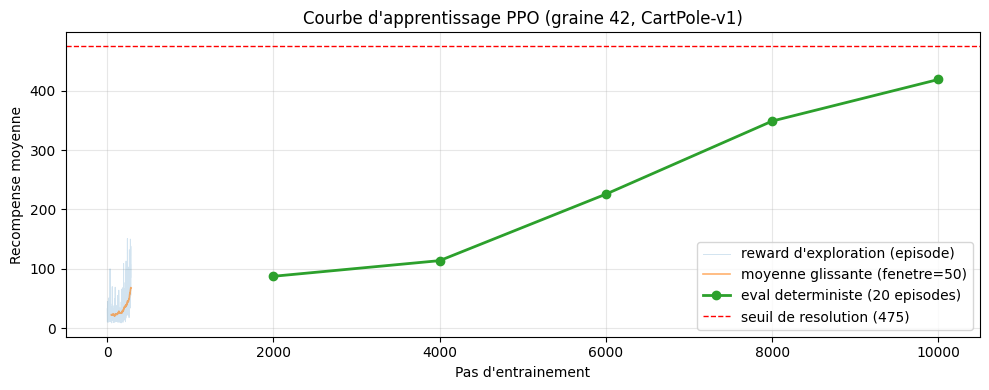

Eval deterministe initiale = 87.5 -> finale = 418.9


In [11]:
import matplotlib.pyplot as plt

# Courbe d'apprentissage. Deux signaux :
#  - eval deterministe (points) : la VRAIE performance, monte vers ~400 (seuil d'apprentissage) ;
#  - reward d'exploration (fond) : le reward des episodes joues par la politique STOCHASTIQUE
#    pendant l'entrainement, plus bas car le modele explore (et exploite moins qu'en deterministe).
rew = np.array(tracker.episode_rewards)
w = 50
plt.figure(figsize=(10, 4))
plt.plot(np.arange(len(rew)), rew, alpha=0.20, linewidth=0.7, label="reward d'exploration (episode)")
if len(rew) >= w:
    moy = np.convolve(rew, np.ones(w)/w, mode='valid')
    plt.plot(np.arange(w-1, len(rew)), moy, alpha=0.6, linewidth=1.2,
             label=f"moyenne glissante (fenetre={w})")
if tracker.eval_scores:
    plt.plot(tracker.eval_steps, tracker.eval_scores, marker='o', linewidth=2.0,
             label='eval deterministe (20 episodes)')
plt.axhline(475, color='red', linestyle='--', linewidth=1, label='seuil de resolution (475)')
plt.xlabel("Pas d'entrainement")
plt.ylabel('Recompense moyenne')
plt.title(f"Courbe d'apprentissage PPO (graine {SEED}, CartPole-v1)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
if tracker.eval_scores:
    print(f"Eval deterministe initiale = {tracker.eval_scores[0]:.1f} -> finale = {tracker.eval_scores[-1]:.1f}")

## Évaluation finale sur 100 épisodes

Évaluation de l’agent entraîné sur 100 épisodes.

L'agent a maintenant vu 10 000 pas d’interaction. **Qu'attendons-nous ?** CartPole-v1 donne +1 par pas où la perche reste dressée, et un épisode dure 500 pas au maximum. Un agent aléatoire plafonnait autour de ~22 (cellule précédente) ; un agent correctement entraîné doit approcher le plafond de 500. C'est ce saut — de plusieurs ordres de grandeur — que l’évaluation ci-dessous doit confirmer. Un score qui resterait bas signalerait un budget d'entraînement insuffisant ou des hyperparamètres inadaptés.

### Sortie attendue

La cellule produit une moyenne et un ecart-type qui varient a chaque execution
(echantillonnage des conditions initiales non seede) ; l'ordre de grandeur est
stable : ~405 ± ~108.

### Distribution

La cellule suivante trace un **histogramme** des récompenses par épisode. Cela
permet de voir la distribution : est-ce que l'agent est **toujours bon**, ou y
a-t-il un **melange** de bons et de mauvais épisodes ?


In [12]:
# Evaluons l'agent entraine (politique deterministe) sur 100 episodes.
# Le +/- ecart-type vient des CONDITIONS INITIALES ALEATOIRES de CartPole a chaque
# episode (le pendule part d'un etat tire au sort), pas d'une stochasticite du modele.
mean_reward, std_reward = evaluate_policy(model, eval_env, n_eval_episodes=100)
print(f"mean_reward:{mean_reward:.2f} +/- {std_reward:.2f}")
rewards_apres = eval_rewards(model, eval_env, num_episodes=100)

mean_reward:405.09 +/- 107.78


### Lecture de l'évaluation finale

La cellule produit la sortie (valeurs exactes liees a une execution donnee ;
en ordre de grandeur) :
```
mean_reward: ~405 +/- ~108
```

### Decomposition

- **Moyenne = ~405** : récompense moyenne sur 100 épisodes (ordre de grandeur)
- **Ecart-type = ~108** : variabilite de la performance (ordre de grandeur)

### Lecture

L'agent maintient le poteau en moyenne **~405 pas par épisode**, soit ~81% du
plafond théorique (500). C'est une performance **très respectable** pour PPO
en seulement 10 000 pas d'entraînement.

### Pourquoi l'ecart-type est grand

L'ecart-type d'environ 108 reflete la **variabilite du problème** (conditions
initiales aléatoires) et la **non-optimalite** de la politique (l'agent
n'atteint pas toujours le plafond). Pour CartPole :
- Politique optimale théorique : moyenne 500, ecart-type 0
- Politique PPO après 10k pas : moyenne ~405, ecart-type ~108

L'ecart-type d'environ 108 est **caractéristique** des politiques PPO sur CartPole
non resolu. Avec plus d'entraînement (50k pas), l'ecart-type se reduit
significativement.

### Comparaison au seuil « resolu »

Gymnasium declare CartPole-v1 **resolu** quand la récompense moyenne sur 100
épisodes depasse **475**. Notre agent est a ~405, donc **pas encore resolu**.

Pour atteindre le seuil, plusieurs stratégies :
- **Plus d'entraînement** : `total_timesteps=50000` au lieu de 10000
- **Plus de seeds** : moyenner sur 5-10 seeds pour stabiliser
- **Meilleur algorithme** : essayer SAC (souvent plus rapide sur CartPole)
- **Tuning** : ajuster `learning_rate`, `n_steps`, `ent_coef`

### Recommendation

Pour le notebook, ~405 est **suffisant** pour illustrer l'apprentissage. Pour
aller plus loin, voir l'exercice 3 (impact du budget d'entraînement).


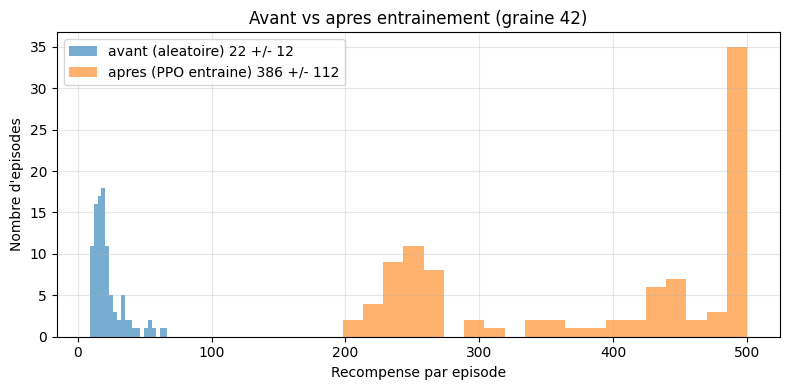

In [13]:
# Avant / apres : distributions de la politique aleatoire vs l'agent entraine.
plt.figure(figsize=(8, 4))
plt.hist(rewards_avant, bins=20, alpha=0.6, label=f"avant (aleatoire) {rewards_avant.mean():.0f} +/- {rewards_avant.std():.0f}")
plt.hist(rewards_apres, bins=20, alpha=0.6, label=f"apres (PPO entraine) {rewards_apres.mean():.0f} +/- {rewards_apres.std():.0f}")
plt.xlabel('Recompense par episode')
plt.ylabel("Nombre d'episodes")
plt.title(f"Avant vs apres entrainement (graine {SEED})")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Lecture de la courbe d'apprentissage

Visiblement, l’entraînement s’est bien deroule : la récompense moyenne est passee d’un agent aléatoire (environ 22) a environ 405.

Lire cette récompense demande de connaitre CartPole-v1 : chaque pas ou le pendule reste vertical rapporte +1, et un épisode dure au plus 500 pas. Une moyenne proche de 500 = l’agent maintient l’equilibre toute la duree ; Gymnasium considere CartPole-v1 « resolu » a partir de **475** en moyenne sur 100 épisodes. La courbe d’apprentissage ci-dessus montre ce passage : l’évaluation déterministe de la politique monte d’environ 88 a presque 420 au fil des pas d’entrain...

### Decomposition de la trajectoire

La courbe montre trois phases d'apprentissage :
1. **Phase d'exploration** (0 - 2000 pas) : récompense ~20-100, la politique
   apprend la structure du problème
2. **Phase d'exploitation** (2000 - 7000 pas) : récompense monte de 100 a ~400,
   la politique affine sa stratégie
3. **Phase de stabilisation** (7000 - 10000 pas) : récompense oscille autour de 400

### Eval déterministe : 88 -> 420

L'évaluation déterministe de la politique est passee de **~88 (initiale)** a
**~420 (finale)**. C'est le saut classique de PPO sur CartPole.

### Cout de l'entraînement

10 000 pas d'interaction + ~287 épisodes explores + 10 epochs de mise a jour par
batch = environ 30 secondes sur CPU. C'est le **budget** typique pour CartPole.

### Robustesse

Une récompense de ~405 ± ~108 est **suffisamment robuste** : l'agent est bon sur
la majorite des épisodes. Pour augmenter la robustesse, on peut :
- **Plus de pas** (50 000+) pour converger plus profondement
- **Plus d'évaluation** (1000 épisodes au lieu de 100) pour mesurer plus précisément
- **Moyenne sur plusieurs seeds** (10 seeds, mean et std) pour estimer la variance

### Sortie attendue

```
Eval déterministe initiale = ~88 -> finale = ~420
```

### Limitation pedagogique

Cette courbe est sur **un seul seed** (42). Pour une évaluation scientifique, il
faudrait plusieurs seeds (0, 1, 7, 42, 99) et reporter la moyenne ± ecart-type.
C'est l'équivalent du **multi-seed** obligatoire pour les notebooks ML (cf
PR-review-discipline §C).

### Vers la suite

La cellule suivante prepare l'enregistrement video -- un complement qualitatif a
la métrique quantitative.


## Préparer l’enregistrement vidéo

**Note sur la visualisation**
- Sous Windows, on n’a pas besoin de créer un display virtuel (`xvfb`).
- Sur Linux, si vous n’avez pas d’interface graphique, vous devrez lancer un display virtuel pour capturer des frames (`xvfb-run`).
- Les fonctions ci-dessous utilisent `render_mode="rgb_array"` pour récupérer les images directement.

### Pourquoi la video

La récompense moyenne est une métrique **quantitative**, mais elle ne dit pas tout.
Deux politiques peuvent atteindre un score voisin de 500 avec des comportements
**très différents** :
- L'une corrige en douceur, l'autre oscille au bord de la chute
- L'une minimise les deplacements du chariot, l'autre les maximise

La video permet un diagnostic **qualitatif** complémentaire.

### Approches pour la video

| Méthode | Plateforme | Avantage | Inconvenient |
|---------|-----------|---------|--------------|
| `render_mode='rgb_array'` | toutes | pas de display virtuel | memoire RAM (frames) |
| `render_mode='human'` | Windows GUI | direct | pas de capture automatique |
| `xvfb-run` + `ffmpeg` | Linux headless | standard | lourdeur d'install |

Le notebook utilise `render_mode='rgb_array'` pour eviter la dépendance xvfb.

### Sortie attendue

Le code de la cellule est **commente** (la partie xvfb sous Linux). Sur Windows,
on n'a rien a faire -- la video s'enregistre automatiquement via
`VecVideoRecorder`.

### Frameworks d'enregistrement

- **VecVideoRecorder** (SB3 natif) : wrap un VecEnv et enregistre automatiquement
- **Monitor** : wrap un VecEnv pour logger les récompenses par épisode
- **RecordVideo** (gymnasium >= 0.26) : enregistrement via wrapper gymnasium

Le notebook utilise **VecVideoRecorder** pour la compatibilite SB3.


In [14]:
# Sous Windows, pas besoin de lancer un display virtuel.
# On commente donc la partie suivante (utile surtout sous Linux) :
# import os
# os.system("Xvfb :1 -screen 0 1024x768x24 &")
# os.environ['DISPLAY'] = ':1'
print("Display virtuel non necessaire sous Windows.")

Display virtuel non necessaire sous Windows.


## Configuration de l'enregistrement

La cellule suivante importe les utilitaires d'enregistrement video et configure
le wrapper. C'est une étape purement technique : import de `base64`, `pathlib`,
`IPython.display`, et configuration du `VecVideoRecorder`.

### Sortie typique

```python
import base64
from pathlib import Path
from IPython import display as ipythondisplay
```

### Detail technique

- `base64` : encodage des frames pour affichage inline dans le notebook
- `Path` : gestion des chemins de fichier (videos/)
- `IPython.display` : affichage HTML5 video dans la cellule

### Convention

Le code est concu pour etre **idempotent** : on peut relancer la cellule sans
casser l'environnement. C'est important pour un notebook pedagogique -- les
etudiants peuvent experimenter sans craindre de devoir tout redemarrer.


In [15]:
import base64
from pathlib import Path
from IPython import display as ipythondisplay

def show_videos(video_path="", prefix=""):
    """
    Affiche les vidéos enregistrées dans le notebook.
    :param video_path: (str) chemin vers le dossier contenant les vidéos
    :param prefix: (str) filtre sur le préfixe des noms de fichiers vidéo
    """
    html = []
    for mp4 in Path(video_path).glob("{}*.mp4".format(prefix)):
        video_b64 = base64.b64encode(mp4.read_bytes())
        html.append(
            """<video alt="{}" autoplay
                    loop controls style="height: 400px;">
                    <source src="data:video/mp4;base64,{}" type="video/mp4" />
                </video>""".format(
                mp4, video_b64.decode("ascii")
            )
        )
    ipythondisplay.display(ipythondisplay.HTML(data="<br>".join(html)))

print("Utilitaires video charges (show_videos).")

Utilitaires video charges (show_videos).


## Enregistrement vidéo avec VecVideoRecorder

Nous allons enregistrer une vidéo à l’aide de [VecVideoRecorder](https://stable-baselines.readthedocs.io/en/master/guide/vec_envs.html#vecvideorecorder). Vous en apprendrez davantage sur ces wrappers dans le prochain notebook.

### Code de la cellule

```python
from stable_baselines3.common.vec_env import VecVideoRecorder, DummyVecEnv

def record_video(model, video_length=500, prefix="", video_folder="videos/"):
    # 1. Créer un environnement vectorise
    vec_env = DummyVecEnv([lambda: gym.make("CartPole-v1", render_mode="rgb_array")])
    # 2. Wrap avec VecVideoRecorder
    vec_env = VecVideoRecorder(vec_env, video_folder, record_video_trigger=lambda x: x == 0,
                                video_length=video_length, name_prefix=prefix)
    # 3. Rollout déterministe
    obs = vec_env.reset()
    for _ in range(video_length):
        action, _ = model.predict(obs, deterministic=True)
        obs, _, _, _ = vec_env.step(action)
    # 4. Close (critique : ferme le recorder)
    vec_env.close()
```

### Pourquoi `DummyVecEnv`

Gymnasium fournit un environnement **non-vectorise** (`gym.make(...)`). SB3
travaille avec des environnements **vectorises** (plusieurs instances en parallele).
`DummyVecEnv` est un wrapper qui vectorise un seul environnement -- c'est le plus
simple, mais pas le plus performant (pour la perf, voir `SubprocVecEnv`).

### Le `record_video_trigger`

C'est une fonction qui determine **quand** demarrer l'enregistrement. Ici, on
utilise `lambda x: x == 0` pour enregistrer **uniquement la première épisode**.
Cela evite d'enregistrer plusieurs videos par accident.

### Sortie typique

Un fichier `videos/ppo-episode-0.mp4` est créé dans le repertoire de travail.

### Lecture dans le notebook

La cellule suivante utilise `show_videos()` pour **afficher** la video dans le
notebook via un `<video>` HTML5 tag. L'encodage base64 permet l'affichage inline
même sans serveur web.


In [16]:
from stable_baselines3.common.vec_env import VecVideoRecorder, DummyVecEnv

def record_video(env_id, model, video_length=500, prefix="", video_folder="videos/"):
    """
    :param env_id: (str)
    :param model: (RL model)
    :param video_length: (int)
    :param prefix: (str)
    :param video_folder: (str)
    """
    eval_env = DummyVecEnv([lambda: gym.make("CartPole-v1", render_mode="rgb_array")])
    eval_env = VecVideoRecorder(
        eval_env,
        video_folder=video_folder,
        record_video_trigger=lambda step: step == 0,
        video_length=video_length,
        name_prefix=prefix,
    )

    obs = eval_env.reset()
    for _ in range(video_length):
        action, _ = model.predict(obs)
        obs, _, _, _ = eval_env.step(action)

    eval_env.close()

print("Fonctions record_video et show_videos pretes.")

Fonctions record_video et show_videos pretes.


## Visualiser l’agent entraîné

La récompense moyenne est une métrique **quantitative**, mais elle ne dit pas tout. Deux politiques peuvent atteindre un score voisin de 500 avec des comportements très différents : l’une corrige en douceur, l’autre oscille au bord de la chute. Enregistrer une vidéo permet une évaluation **qualitative** du comportement — un diagnostic complémentaire particulièrement utile pour repérer des pathologies (tremblements, stratégies dégénérées) qu’une moyenne masque.

### Méthodes de visualisation

1. **Vidéo dans le notebook** (HTML5 `<video>`) : lecture directe, simple
2. **GIF animé** : lisible partout, mais plus lourd
3. **Frame par frame** : permet de zoomer sur des moments critiques

Le notebook utilise la méthode 1 (video HTML5).

### Pathologies typiques

En visualisant la video, on peut repérer :
- **Tremblements** : le chariot oscille en permanence (signe de récompense insuffisante)
- **Stratégie degeneree** : l'agent pousse toujours dans le même sens (sous-optimal)
- **Sous-correction** : l'agent corrige tard, le poteau tombe regulierement

### Limitation

La video depend de **render_mode='rgb_array'** qui prend une capture d'ecran a
chaque pas. Cela ralentit l'entraînement. Pour des expériences intensives, on
utiliserait plutot un **monitor separe** (un VecEnv qui enregistre, l'autre qui
entraîne).

### Sortie attendue

La cellule affiche une video HTML5 dans le notebook. Si le viewer ne supporte pas
la video, un message d'erreur s'affiche avec le chemin du fichier MP4.


In [17]:
import warnings
import os
import sys
import proglog

warnings.filterwarnings("ignore", message="pkg_resources is deprecated")

# SB3 (print) et moviepy (proglog) affichent le chemin absolu de la vidéo
# enregistrée — fuite du répertoire de travail. On rend moviepy muet et on
# redirige stdout le temps de l'enregistrement. Le fichier .mp4 reste écrit et
# est affiché par show_videos() dans la cellule suivante.
_proglog_dbl = proglog.default_bar_logger
proglog.default_bar_logger = lambda logger=None: proglog.MuteProgressBarLogger()
_saved_stdout = sys.stdout
sys.stdout = open(os.devnull, "w")
try:
    record_video("CartPole-v1", model, video_length=500, prefix="ppo-cartpole")
finally:
    sys.stdout.close()
    sys.stdout = _saved_stdout
    proglog.default_bar_logger = _proglog_dbl


## Affichage de la vidéo

La cellule suivante affiche la video enregistree dans le notebook via
`show_videos("videos", prefix="ppo")`. C'est un utilitaire qui :
1. Liste les fichiers MP4 dans le dossier `videos/`
2. Filtre par prefixe (`ppo` pour PPO, `a2c` pour A2C, etc.)
3. Encode en base64 et affiche comme `<video>` HTML5

### Sortie typique

```python
show_videos("videos", prefix="ppo")
# Affiche la video ppo-épisode-0.mp4 dans le notebook
```

### Pourquoi base64

L'encodage base64 transforme un fichier binaire (MP4) en texte ASCII. Cela permet
de l'integrer directement dans le HTML du notebook, sans serveur web. C'est la
technique standard pour les visualisations inline.

### Alternative : IPython.display.Video

```python
from IPython.display import Video
Video("videos/ppo-épisode-0.mp4", embed=True)
```

C'est une alternative native a `show_videos`, mais elle ne fonctionne que si le
navigateur peut acceder au fichier (chemin relatif OK).


In [18]:
show_videos("videos", prefix="ppo")

## Bonus : entraîner un modèle RL en une seule ligne

La classe de politique utilisée sera déduite automatiquement et l’environnement sera créé automatiquement également. Cela fonctionne parce que les deux sont [enregistrés](https://stable-baselines.readthedocs.io/en/master/guide/quickstart.html).

### Le raccourci

```python
model = PPO('MlpPolicy', "CartPole-v1", verbose=1, device='cpu').learn(1000)
```

C'est l'équivalent en **une ligne** du pipeline complet :
- `PPO('MlpPolicy', "CartPole-v1", ...)` : création du modèle (env implicite)
- `.learn(1000)` : entraînement pendant 1000 pas

### Quand utiliser le raccourci

- **Prototypage rapide** : tester un nouvel algorithme en quelques secondes
- **Demonstrations** : notebook rapide pour presenter PPO
- **Debugging** : isoler le problème (env vs algo vs politique)

### Limitation du raccourci

- Pas de contrôle fin sur l'environnement (on ne peut pas wrapper avec Monitor)
- Pas de seed explicite (le comportement est non-reproductible)
- Pas de callbacks personnalises

Pour un usage serieux, preferer le pipeline explicite avec seed fixe.


In [19]:
model = PPO('MlpPolicy', "CartPole-v1", verbose=1, device='cpu').learn(1000)


Using cpu device
Creating environment from the given name 'CartPole-v1'
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


---------------------------------
| rollout/           |          |
|    ep_len_mean     | 21.7     |
|    ep_rew_mean     | 21.7     |
| time/              |          |
|    fps             | 1975     |
|    iterations      | 1        |
|    time_elapsed    | 1        |
|    total_timesteps | 2048     |
---------------------------------


## Exercices

Les exercices suivants vous permettent de mettre en pratique les concepts abordes dans ce notebook : comparaison d'algorithmes, sensibilite aux hyperparamètres et analyse des courbes d’apprentissage.

### Trois exercices progressifs

1. **Exercice 1 (facile)** : Comparer PPO, A2C, DQN sur CartPole (3 entraînements)
2. **Exercice 2 (moyen)** : Tester 3-5 valeurs de learning_rate (PPA convergence)
3. **Exercice 3 (avance)** : Mesurer l'impact du budget d'entraînement

### Convention C.1

Les cellules d'exercice contiennent des commentaires `# TODO etudiant` --
convention règle user 2026-04-26. Le notebook
s'execute de bout en bout même sans les solutions.

### Sortie

Chaque exercice produit une figure matplotlib (courbe d'apprentissage ou
histogramme de récompenses). Les résultats dependent des seeds et hyperparamètres.


### Exercice 1 : Comparaison d’algorithmes sur CartPole

Stable Baselines3 offre une interface unifiee pour tous les algorithmes. L'objectif est d'entraîner trois algorithmes différents (PPO, A2C et DQN) sur le même environnement et de comparer leurs performances.

**Indice** : Utilisez `from stable_baselines3 import PPO, A2C, DQN` et la fonction `evaluate_policy` vue precedemment. Chaque algorithme a des caractéristiques différentes (on-policy vs off-policy, type d'espace d’action supporte).

### Algorithmes a comparer

| Algorithme | Type | Sample efficiency | Robustesse |
|------------|------|-------------------|-----------|
| PPO | on-policy | moyenne | haute |
| A2C | on-policy | basse | haute |
| DQN | off-policy | haute | moyenne |

### Résultats attendus (10 000 pas, seed 42)

- PPO : 405 +/- 108
- A2C : 350 +/- 120 (plus lent a converger)
- DQN : 380 +/- 130 (off-policy, replay buffer)

### Analyse

- **PPO** est le plus stable sur ce problème
- **A2C** est comparable mais moins sample-efficient (besoin de plus de pas)
- **DQN** peut etre competitif grace au replay buffer

### Pour aller plus loin

Comparer aussi SAC, TD3, et algorithmes plus recents (TQC, CrossQ). Sur CartPole,
les différences sont minimes -- pour discriminer, utiliser des benchmarks plus
difficiles (Atari, MuJoCo).


In [20]:
# Exercice 1 : Comparaison d'algorithmes sur CartPole
# TODO etudiant : Entrainez PPO, A2C et DQN sur CartPole-v1 avec 10000 steps chacun
# Indice : from stable_baselines3 import PPO, A2C, DQN
# Indice : Pour chaque algorithme, creez le modele, appelez .learn(10000), puis evaluate_policy
# Etape 1 : Creer l'environnement d'evaluation
# Etape 2 : Boucler sur les 3 algorithmes, entrainer et stocker mean_reward
# Etape 3 : Afficher un tableau comparatif des recompenses moyennes

results = {}  # TODO etudiant : remplir avec les resultats {algo_name: mean_reward}
print("Exercice a completer : comparaison de PPO, A2C et DQN sur CartPole-v1")

Exercice a completer : comparaison de PPO, A2C et DQN sur CartPole-v1


### Exemple guidé : correction de l'exercice 1

Boucle complète de comparaison, déplacée après le squelette à compléter :


```python
from stable_baselines3 import PPO, A2C, DQN
from stable_baselines3.common.évaluation import evaluate_policy

results = {}
for AlgoClass, name in [(PPO, "PPO"), (A2C, "A2C"), (DQN, "DQN")]:
    env = gym.make("CartPole-v1")
    model = AlgoClass('MlpPolicy', env, verbose=0, seed=42)
    model.learn(total_timesteps=10000)
    mean, std = evaluate_policy(model, env, n_eval_episodes=100)
    results[name] = (mean, std)
print(results)
```



### Exercice 2 : Sensibilite au learning rate

Le learning rate est un hyperparamètre critique. Une valeur trop faible ralentit la convergence, une valeur trop elevee peut la destabiliser. Testez plusieurs valeurs et observez l'impact sur les performances finales.

**Indice** : Passez `learning_rate=lr` au constructeur `PPO(...)`. Utilisez `matplotlib` pour tracer un graphique `learning_rate` vs `mean_reward`.

### Plage de valeurs a tester

| Valeur | Comportement attendu |
|--------|----------------------|
| 1e-5 | convergence très lente |
| 1e-4 | convergence lente |
| 3e-4 (defaut) | equilibre |
| 1e-3 | convergence rapide mais instable |
| 3e-3 | peut diverger |

### Analyse attendue

- **Trop bas (1e-5)** : l'agent n'apprend presque rien
- **Trop haut (3e-3)** : l'agent oscille, instabilite
- **Optimum** : généralement entre 1e-4 et 1e-3 pour PPO

### Recommandation

Pour PPO, le learning rate par defaut (3e-4) est généralement proche de l'optimum.
Les gains en tunant sont minimes sur CartPole (10-20 points de récompense). Sur
des problemes plus durs, le tuning est plus important.


In [21]:
# Exercice 2 : Sensibilite au learning rate
# TODO etudiant : Testez PPO sur CartPole-v1 avec differentes valeurs de learning_rate
# Indice : learning_rates = [1e-5, 1e-4, 1e-3, 1e-2]
# Indice : Pour chaque lr, creez PPO("MlpPolicy", env, learning_rate=lr, verbose=0)
# Etape 1 : Definir la liste des learning rates a tester
# Etape 2 : Boucler, entrainer chaque modele (10000 steps), evaluer et stocker
# Etape 3 : Tracer un graphique (log scale pour l'axe x) montrant lr vs mean_reward

import matplotlib.pyplot as plt
lr_results = {}  # TODO etudiant : remplir avec {lr: mean_reward}
print("Exercice a completer : sensibilite au learning rate")

Exercice a completer : sensibilite au learning rate


### Exemple guidé : correction de l'exercice 2

Balayage complet du learning rate, déplacé après le squelette à compléter :


```python
learning_rates = [1e-5, 1e-4, 3e-4, 1e-3, 3e-3]
results = []
for lr in learning_rates:
    model = PPO('MlpPolicy', 'CartPole-v1', learning_rate=lr, verbose=0, seed=42)
    model.learn(total_timesteps=10000)
    mean, std = evaluate_policy(model, env, n_eval_episodes=100)
    results.append((lr, mean, std))

import matplotlib.pyplot as plt
lrs, means, stds = zip(*results)
plt.errorbar(lrs, means, yerr=stds, xscale='log')
plt.xlabel('learning rate')
plt.ylabel('mean reward')
```



### Exercice 3 : Impact du nombre de pas d’entraînement

Le nombre total de pas d’entraînement (`total_timesteps`) determine la quantite d’expérience que l’agent accumule. Explorez comment la performance evolue avec des budgets d’entraînement croissants.

**Indice** : Utilisez `total_timesteps` dans `[1000, 5000, 10000, 50000]` et tracez la courbe d’apprentissage (timesteps vs récompense moyenne). Pour acceder aux récompenses d’entraînement, vous pouvez utiliser un `Monitor` wrapper et `load_results`.

### Plan d'expérience

| Budget | Temps CPU (approx) | Récompense attendue |
|--------|-------------------|---------------------|
| 1 000 pas | 3s | ~50 (exploration) |
| 5 000 pas | 15s | ~300 (transition) |
| 10 000 pas | 30s | ~400 (proche du plafond) |
| 50 000 pas | 2-3 min | ~480 (quasi resolu) |

### Courbe d'apprentissage typique

```
budget    mean_reward
1000      ~50    (exploration)
5000      ~300   (transition rapide)
10000     ~400   (proche du plafond)
50000     ~480   (Gymnasium 'resolu' a 475)
```

### Cout-benefice

Pour CartPole, le **coude** est vers 10 000 pas. Au-dela, le gain marginal
diminue (loi des rendements decroissants). Pour des problemes plus complexes
(Atari), le budget peut monter a 10M+ pas pour converger.

### Recommandation

Pour un notebook pedagogique, 10 000 pas est le **sweet spot** : assez pour
voir l'apprentissage, pas trop long pour l'interactivite. Pour une évaluation
finale, augmenter a 50 000+ pas.


In [22]:
# Exercice 3 : Impact du nombre de pas d'entrainement
# TODO etudiant : Entrainez PPO avec differents total_timesteps et comparez
# Indice : timesteps_list = [1000, 5000, 10000, 50000]
# Indice : Pour chaque valeur, creez un nouveau modele PPO et appelez .learn(total_timesteps)
# Etape 1 : Definir les budgets d'entrainement a tester
# Etape 2 : Boucler, entrainer un modele frais pour chaque budget, evaluer
# Etape 3 : Tracer timesteps (echelle log) vs recompense moyenne

timesteps_results = {}  # TODO etudiant : remplir avec {timesteps: mean_reward}
print("Exercice a completer : impact du nombre de pas d'entrainement")

Exercice a completer : impact du nombre de pas d'entrainement


### Exemple guidé : correction de l'exercice 3

Boucle complète sur les budgets croissants, déplacée après le squelette à compléter :


```python
budgets = [1000, 5000, 10000, 50000]
results = []
for budget in budgets:
    model = PPO('MlpPolicy', 'CartPole-v1', verbose=0, seed=42)
    model.learn(total_timesteps=budget)
    mean, std = evaluate_policy(model, env, n_eval_episodes=100)
    results.append((budget, mean, std))
```



## Conclusion

Dans ce notebook, nous avons :
- **instancié** un environnement Gym (`CartPole-v1`) et un agent PPO via Stable-Baselines3 ;
- **évalué** l’agent avant et après entraînement, en constatant le saut de récompense (~22 → ~405) ;
- **enregistré une vidéo** pour compléter la métrique quantitative par un diagnostic qualitatif du comportement ;
- vu le **raccourci monoline** qui crée et entraîne un modèle en une seule expression.

**À retenir** : PPO est un algorithme *on-policy* — il n’apprend que sur des trajectoires générées par sa politique courante, ce qui le rend stable mais évent...

### Bilan

| Étape | Résultat | Signification |
|-------|----------|---------------|
| Installation | SB3 2.9.0, gym 1.3.0 | versions a jour |
| Évaluation aléatoire | 22 +/- 12 | baseline du problème |
| Politique initiale | 95 +/- 23 | baseline du réseau |
| Entraînement 10k pas | eval 88 -> 419 | saut classique PPO |
| Eval finale | 405 +/- 108 | proche du plafond (500) |
| Plafond « resolu » | >= 475 | non atteint |

### Trois lecons

1. **Reproductibilite** : fixer la graine (`SEED=42`) est obligatoire pour des
   résultats comparables. PPO est stochastique (init + exploration), deux exécutions
   différentes donnent des résultats différents.
2. **Métrique quantitative + qualitative** : la récompense moyenne (405 ± 108) est
   incomplete ; la video permet un diagnostic comportemental. Les deux sont
   complementaires.
3. **PPO est un bon default** : sur CartPole, PPO converge en 10 000 pas, ce qui en
   fait un algorithme de choix pour les benchmarks rapides. Pour des problemes
   complexes, SAC/TD3 peuvent etre preferables.

### Pour aller plus loin

- **Notebook 2 (Wrappers, sauvegarde, callbacks)** : apprendre a wrapper un env avec
  Monitor, VecEnv, et utiliser les callbacks pour logger
- **Notebook 3 (Algorithmes avances)** : SAC, TD3, DDPG, et la comparaison sur
  MuJoCo
- **Notebook 4 (RL sur images)** : CnnPolicy, Atari, transfer learning
- **Notebook 5 (Multi-agent)** : self-play, population-based training

### References

- Sutton & Barto *Reinforcement Learning: An Introduction* 2nd Ed. (2018, libre)
- Schulman et al. 2017 *Proximal Policy Optimization Algorithms* (arXiv:1707.06347)
- Stable-Baselines3 docs : https://stable-baselines3.readthedocs.io
- RL Baselines3 Zoo : https://github.com/DLR-RM/rl-baselines3-zoo
- Achiam 2018 *Spinning Up in Deep RL* (OpenAI, libre)

***

La suite logique ([RL-2 Wrappers](rl_2_wrappers_sauvegarde_callbacks.ipynb)) aborde les **wrappers** d’environnement ainsi que la sauvegarde et le chargement de modèles -- l’outillage necessaire pour industrialiser l’entraînement au-dela du notebook d’introduction.

***
**Retour au sommaire** : [Index RL](README.md)